In [106]:
from google.colab import drive
drive.mount('/content/drive')
# libs from description

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import math

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [107]:
#functions

def hough_circles_acc(edge_img, r_min, r_max):
    height, width = edge_img.shape
    num_r = r_max - r_min + 1
    accumulator = np.zeros((height, width, num_r), dtype=np.uint64)

    edge_points = np.argwhere(edge_img > 0)
    thetas = np.deg2rad(np.arange(0, 360))
    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)

    for y, x in edge_points:
        for r_index, r in enumerate(range(r_min, r_max + 1)):
            xc_vals = np.round(x - r * cos_t).astype(int)
            yc_vals = np.round(y - r * sin_t).astype(int)

            valid = (xc_vals >= 0) & (xc_vals < width) & \
                    (yc_vals >= 0) & (yc_vals < height)

            np.add.at(accumulator, (yc_vals[valid], xc_vals[valid], r_index), 1)

    return accumulator


def hough_circles_peaks(accumulator, r_min, t, s, min_dist=50):
    circles = []
    yc_idx, xc_idx, r_idx = np.where(accumulator >= t)
    if len(yc_idx) == 0:
        return circles

    votes = accumulator[yc_idx, xc_idx, r_idx]
    sorted_indices = np.argsort(votes)[::-1]

    for i in sorted_indices:
        yc = int(yc_idx[i])
        xc = int(xc_idx[i])
        r = int(r_idx[i]) + r_min
        v = int(votes[i])

        too_close = False
        for (ex, ey, er, _) in circles:
            if math.hypot(xc - ex, yc - ey) < min_dist:
                too_close = True
                break

        if not too_close:
            circles.append((xc, yc, r, v))

        if len(circles) >= s:
            break

    return circles



def draw_circles(img, circles):
    output = img.copy()
    for (x, y, r, _) in circles:
        cv2.circle(output, (x, y), r, (0, 255, 0), 2)
        cv2.circle(output, (x, y), 2, (0, 0, 255), 3)
    return output



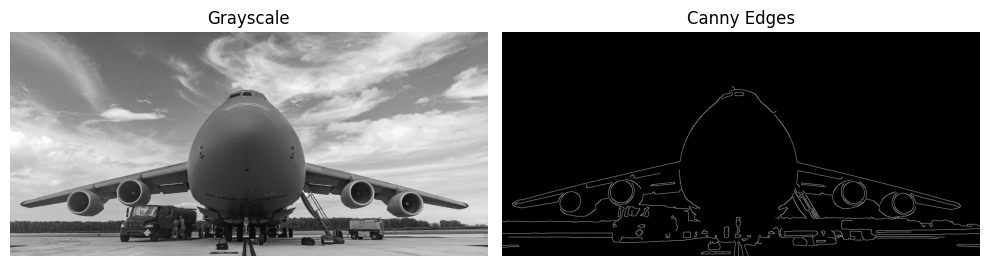

Image shape: (668, 1425, 3)


In [104]:
img = cv2.imread('/content/drive/MyDrive/Colab Notebooks/CS423/plane2.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (9, 9), 2)

canny = cv2.Canny(blurred, 50, 150)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(gray, cmap='gray');   plt.title("Grayscale"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(canny, cmap='gray');  plt.title("Canny Edges"); plt.axis("off")
plt.tight_layout(); plt.show()

print("Image shape:", img.shape)

In [96]:
img.shape

(668, 1425, 3)

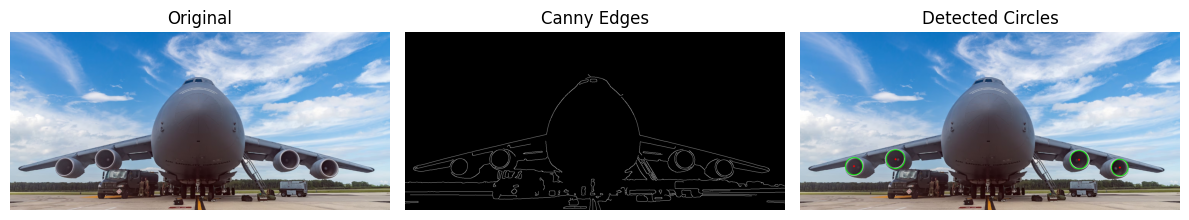

In [105]:
r_min, r_max = 20, 50
t = int(126)

acc = hough_circles_acc(canny, r_min=r_min, r_max=r_max)
circles = hough_circles_peaks(acc, r_min=r_min, t=30, s=4, min_dist=60)

result = draw_circles(img, circles)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB));    plt.title("Original");      plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(canny, cmap="gray");                       plt.title("Canny Edges");   plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); plt.title("Detected Circles"); plt.axis("off")
plt.tight_layout(); plt.show()